# Data preprocessing

We are going to start Preprocessing the data from the "liar" dataset in order to make it ready for the model, while following the README.md file.

Below we will import all required modules for this notebook:

In [100]:
import pandas as pd

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from xgboost import XGBClassifier

import numpy as np
import matplotlib.pyplot as plt


## Importing Data (TEST + TRAIN)

In [146]:
# In the "liar" dataset, we know the columns are ordered as follows:
columns = [
    'id',
    'label',
    'statement',
    'subject',
    'speaker',
    'job_title',
    'state',
    'party',
    'barely_true_counts',
    'false_counts',
    'half_true_counts',
    'mostly_true_counts',
    'pants_on_fire_counts',
    'context'
]

df_train = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/train.tsv', sep='\t', header=None, names=columns))
df_test = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/test.tsv', sep='\t', header=None, names=columns))
df_val = pd.DataFrame(pd.read_csv('/home/mnavarrosotes/code/navaso93/final_project/liar_project/raw_data/liar/valid.tsv', sep='\t', header=None, names=columns))

print("Shape of TRAIN dataset is: ", df_train.shape)
print("Shape of TEST dataset is: ", df_test.shape)
print("Shape of validation dataset is: ", df_val.shape)

df_tt = pd.concat([df_train, df_test], ignore_index=True)
df = pd.concat([df_tt, df_val], ignore_index=True)

print("Shape of merged dataset is: ", df.shape)

Shape of TRAIN dataset is:  (10240, 14)
Shape of TEST dataset is:  (1267, 14)
Shape of validation dataset is:  (1284, 14)
Shape of merged dataset is:  (12791, 14)


## Text Preprocessing

As mentionned in the README.md file, we will apply the following sequence to all text features:
- **strip:** Removes all whitespaces at the beginning anfd the end of a string. You can also specify a list of characters to be removed at the beginning and end of a string (RECOMMENDED)
- **replace:** Can be used to replace some words by another.
- **split:** Used to split a text into a lsit, where each word is an item.
- **numbers:** Numbers should be removed during text preprocessing steps.
- **punctuation and symbols:** Punctuation and other symbols should be removed for text preprocessing.

In [102]:
text_col = [
    'statement',
    'subject',
    'speaker',
    'job_title',
    'state',
    'party',
    'context'
]

for col in text_col:
    df[col] = (
        df[col]
        .fillna("")
        .str.lower()
        .str.strip()
        .str.replace(r"\d+", "", regex=True) # We replace numbers by empty values
        .str.replace(r"[^\w\s]", " ", regex=True) # We replace punctuation by blank spaces, since it might separate two words.
    )

# We remove ".json" from "id":
df["id"] = df["id"].str.removesuffix(".json")

In [103]:
df["label"].value_counts(normalize=True)

label
half-true      0.205379
false          0.195997
mostly-true    0.191854
barely-true    0.164412
true           0.160503
pants-fire     0.081854
Name: proportion, dtype: float64

### Specific column fixes

#### State

Some state names are differently typed for the same state (we have 84 different states!!!), or have other issues that cause the model to loose context. We should cluster the state names only into the valid names:

In [104]:
from rapidfuzz import process

# Function that finds the closest valid state name
def correct_state(state):

    valid_states = [
    "alabama", "alaska", "arizona", "arkansas", "california", "colorado", "connecticut", "delaware", "florida",
    "georgia", "hawaii", "idaho", "illinois", "indiana", "iowa", "kansas", "kentucky",
    "louisiana", "maine", "maryland", "massachusetts", "michigan", "minnesota", "mississippi", "missouri",
    "montana", "nebraska", "nevada", "new hampshire", "new jersey",
    "new mexico", "new york", "north carolina", "north dakota", "ohio",
    "oklahoma", "oregon", "pennsylvania", "rhode island", "south carolina",
    "south dakota", "tennessee", "texas", "utah", "vermont",
    "virginia", "washington", "west virginia", "wisconsin", "wyoming"
    ]
    # Handle missing values
    if pd.isna(state):
        return state

    # Convert to lowercase and remove spaces around the test
    state = str(state).lower().strip()

    # Find the closest match from the valid states list
    match, score, _ = process.extractOne(state, valid_states)

    # Only replace if similarity is high enough
    # We will be flexible and apply a similarity threshold of 75%
    if score >= 80:
        return match

    # Otherwise keep original value
    return state

#### Job Title

The values in the Job Title column are too scattered and non uniform. This prevents the model from gaining important context for the predictions.
We are going to try and cluster all the values into a smaller group:

In [105]:
def simplify_job_title(title):

    if pd.isna(title):
        return "unknown"

    if title in ["president", "president elect", "presidential candidate", "former president"]:
        return "president"

    elif "governor" in title:
        return "governor"

    elif "senator" in title:
        return "senator"

    elif "legislator" in title:
        return "legislator"

    elif 'mayor' in title:
        return 'mayor'

    elif 'ambassador' in title:
        return 'ambassador'

    elif any(x in title for x in ["representative", "congressman", "congresswoman", "house"]):
        return "representative"

    elif "attorney" in title or "lawyer" in title:
        return "legal"

    elif any(x in title for x in ["radio host", "host", "journalist", "reporter", "blog", 'social', 'columnist']):
        return "media"

    elif any(x in title for x in ['president', 'ceo', 'director', 'founder', 'business']):
        return 'private executive'

    elif "candidate" in title:
        return "candidate"

    else:
        return "other"

#### Context

We initially have 3842 different values for context, which are far too many for the model to grasp any relevant context when generalizing.
Similarly to the previous features, we will cluster those into a far smaller numebr of possible options.

In [106]:
# Function to simplify context values into broader categories
def simplify_context(context):

    # Handle missing values
    if pd.isna(context):
        return "unknown"

    # Convert to Lowercase for consistent matching
    context = str(context).lower()

    # Ads and commercials
    if any(x in context for x in ["ad", "commercial", "mailer"]):
        return "ad"

    # Interviews
    elif "interview" in context:
        return "interview"

    # Speeches and remarks
    elif any(x in context for x in ["press release", "news release"]):
        return "press release"

    # Press and news conferences
    elif any(x in context for x in ["press conference", "news conference"]):
        return "news conference"

    # Debates
    elif "debate" in context:
        return "debate"

    # Social media and websites
    elif any(x in context for x in ["tweet", "facebook", "website", "social"]):
        return "social media"

    # Statements
    elif "statement" in context:
        return "statement"

    # Emails
    elif any(x in context for x in ["email", " e mail", "chain mail"]):
        return "email"

    # TV appearances
    elif any(x in context for x in ["television", "tv", "fox news", "cnn", "meet the press"]):
        return "tv appearance"

    # Everything else
    else:
        return "other"

#### Party

Initially, the dataset has 25 different (unique) values for the "party" column, which are too many. We should cluster this into fewer categories:

In [107]:
# Function to simplify party affiliations into 5 broad categories
def simplify_party(party):

    # Handle missing values
    if pd.isna(party):
        return "unknown"

    # Convert to lowercase for consistent matching
    party = str(party).lower()

    # Republicans and related groups
    if any(x in party for x in ["republican", "tea party"]):
        return "republican"

    # Democrats and related groups
    elif any(x in party for x in ["democrat", "democratic farmer labor"]):
        return "democrat"

    # Other political parties
    elif any(x in party for x in ["independent", "libertarian", "green", "constitution party", "moderate"]):
        return "other_party"

    # Non-party entities, professions and organizations
    elif any(x in party for x in ["organization", "journalist", "columnist", "newsmaker", "activist", "talk show host", "state official", "education official",
        "government body", "business leader", "labor leader", "commissioner"]):
        return "organization"

    # Missing or unknown affiliation
    elif party == "none":
        return "unknown"

    # Catch any remaining rare values
    else:
        return "other"

#### Subject

There are initially 4144 different subjects. This is an excessively high number, especially considering that lots of them are the same, but written diffrently. We will try to cluster the main categories to avoid repetition under different wording.

In [108]:
# Function to simplify subjects into broader topic groups
def simplify_subject(subject):

    # Handle missing values
    if pd.isna(subject):
        return "unknown"

    # Convert to lowercase for consistent matching
    subject = str(subject).lower()

    # Health
    if any(x in subject for x in ["health", "medicare", "medicaid", "hospital", "disease", "ebola"]):
        return "health"

    # Economy and jobs
    elif any(x in subject for x in ["economy", "job", "worker", "small business", "income"]):
        return "economy"

    # Taxation
    elif "tax" in subject:
        return "taxation"

    # Budget and finance
    elif any(x in subject for x in ["budget", "finance", "deficit", "debt"]):
        return "budget"

    # Education
    elif "education" in subject:
        return "education"

    # Immigration
    elif any(x in subject for x in ["immigration", "border", "refugee"]):
        return "immigration"

    # Elections and campaigns
    elif any(x in subject for x in ["election", "candidate biography", "campaign", "voting record"]):
        return "elections"

    # Security and crime
    elif any(x in subject for x in ["crime", "criminal justice", "terrorism", "gun", "public safety"]):
        return "security"

    # Foreign affairs
    elif any(x in subject for x in ["foreign policy", "iraq", "afghanistan", "china", "israel", "trade"]):
        return "foreign_affairs"

    # Environment and climate
    elif any(x in subject for x in ["environment", "climate", "weather"]):
        return "environment"

    # Energy
    elif "energy" in subject:
        return "energy"

    # Transportation
    elif "transportation" in subject:
        return "transportation"

    # Military and veterans
    elif any(x in subject for x in ["military", "veteran", "defense"]):
        return "military"

    # Government and politics
    elif any(x in subject for x in ["government", "ethic", "legal issue", "congress"]):
        return "government"

    # Social issues
    elif any(x in subject for x in ["abortion", "religion", "gay", "lesbian", "woman", "queer", "marriage"]):
        return "social_issues"

    # Science and technology
    elif any(x in subject for x in ["science", "technology", "research"]):
        return "science"

    # Everything else
    else:
        return "other"

#### Label

The label ahs currently 6 categories,a nd for the model to properly distinguish between e.g. a "partly-true" statement and a "mostly-true" statement, it can be hard (it is even for humans!). 
We will cluster the label into 3 categories:

In [ ]:
def simplify_label(label):
    if label in ["true", "mostly-true"]:
        return "trustworthy"

    elif label == "half-true":
        return "questionable"

    else:
        return "unreliable"

##### Establishing new baseline score

Now that we have clustered the new labels into only 3 different categories, we can re-assess the basleine score. We should at the very least aim higher than this:

In [140]:
baseline_score = 1 / len(df["label"].unique())
baseline_score

0.3333333333333333

#### Speaker truthfulness score

As there are some NaN values in the counter of statement truthfulness for each speaker, we will remove them and assume them as zero. This will allow us to later use the ColumnTransformer.

In [110]:

def fill_speaker_history(df):

    score_cols = [
        "barely_true_counts",
        "false_counts",
        "half_true_counts",
        "mostly_true_counts",
        "pants_on_fire_counts"
    ]

    df[score_cols] = df[score_cols].fillna(0)

    return df

### We apply the column simplifier functions

In [111]:
df["state"] = df["state"].apply(correct_state)
df["job_title"] = df["job_title"].apply(simplify_job_title)
df["context"] = df["context"].apply(simplify_context)
df["party"] = df["party"].apply(simplify_party)
df["subject"] = df["subject"].apply(simplify_subject)
df["label"] = df["label"].apply(simplify_label)
df = fill_speaker_history(df)


## Tokenizing

In [112]:
col_tk = ['statement', 'subject', 'speaker', 'job_title', 'state', 'context']

for col in col_tk:
    df[col] = df[col].fillna("").apply(word_tokenize)

df.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635,unreliable,"[says, the, annies, list, political, group, su...",[social_issues],"[dwayne, bohac]",[representative],[texas],republican,0.0,1.0,0.0,0.0,0.0,[ad]
1,10540,questionable,"[when, did, the, decline, of, coal, start, it,...",[economy],"[scott, surovell]",[other],[virginia],democrat,0.0,0.0,1.0,1.0,0.0,[other]
2,324,trustworthy,"[hillary, clinton, agrees, with, john, mccain,...",[foreign_affairs],"[barack, obama]",[president],[illinois],democrat,70.0,71.0,160.0,163.0,9.0,[other]
3,1123,unreliable,"[health, care, reform, legislation, is, likely...",[health],"[blog, posting]",[other],[],unknown,7.0,19.0,3.0,5.0,44.0,"[press, release]"
4,9028,questionable,"[the, economic, turnaround, started, at, the, ...",[economy],"[charlie, crist]",[other],[florida],democrat,15.0,9.0,20.0,19.0,2.0,[interview]


## Stopwords

In [113]:
stop_words = set(stopwords.words('english'))

for col in col_tk:
    df[col] = df[col].apply(lambda tokens: [w for w in tokens if w not in stop_words])

df.head()


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635,unreliable,"[says, annies, list, political, group, support...",[social_issues],"[dwayne, bohac]",[representative],[texas],republican,0.0,1.0,0.0,0.0,0.0,[ad]
1,10540,questionable,"[decline, coal, start, started, natural, gas, ...",[economy],"[scott, surovell]",[],[virginia],democrat,0.0,0.0,1.0,1.0,0.0,[]
2,324,trustworthy,"[hillary, clinton, agrees, john, mccain, votin...",[foreign_affairs],"[barack, obama]",[president],[illinois],democrat,70.0,71.0,160.0,163.0,9.0,[]
3,1123,unreliable,"[health, care, reform, legislation, likely, ma...",[health],"[blog, posting]",[],[],unknown,7.0,19.0,3.0,5.0,44.0,"[press, release]"
4,9028,questionable,"[economic, turnaround, started, end, term]",[economy],"[charlie, crist]",[],[florida],democrat,15.0,9.0,20.0,19.0,2.0,[interview]


## Lemmatize

In [114]:
lemmatizer = WordNetLemmatizer()

In [115]:
for col in col_tk:
    df[col] = df[col].apply(lambda tokens: [WordNetLemmatizer().lemmatize(w) for w in tokens])

df.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635,unreliable,"[say, annies, list, political, group, support,...",[social_issues],"[dwayne, bohac]",[representative],[texas],republican,0.0,1.0,0.0,0.0,0.0,[ad]
1,10540,questionable,"[decline, coal, start, started, natural, gas, ...",[economy],"[scott, surovell]",[],[virginia],democrat,0.0,0.0,1.0,1.0,0.0,[]
2,324,trustworthy,"[hillary, clinton, agrees, john, mccain, votin...",[foreign_affairs],"[barack, obama]",[president],[illinois],democrat,70.0,71.0,160.0,163.0,9.0,[]
3,1123,unreliable,"[health, care, reform, legislation, likely, ma...",[health],"[blog, posting]",[],[],unknown,7.0,19.0,3.0,5.0,44.0,"[press, release]"
4,9028,questionable,"[economic, turnaround, started, end, term]",[economy],"[charlie, crist]",[],[florida],democrat,15.0,9.0,20.0,19.0,2.0,[interview]


# Vectorizing

First, columns, need to be put back as a string, not a list.

In [116]:
for col in col_tk:
    df[col] = df[col].apply(lambda token: " ".join(token))

df.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635,unreliable,say annies list political group support third ...,social_issues,dwayne bohac,representative,texas,republican,0.0,1.0,0.0,0.0,0.0,ad
1,10540,questionable,decline coal start started natural gas took st...,economy,scott surovell,,virginia,democrat,0.0,0.0,1.0,1.0,0.0,
2,324,trustworthy,hillary clinton agrees john mccain voting give...,foreign_affairs,barack obama,president,illinois,democrat,70.0,71.0,160.0,163.0,9.0,
3,1123,unreliable,health care reform legislation likely mandate ...,health,blog posting,,,unknown,7.0,19.0,3.0,5.0,44.0,press release
4,9028,questionable,economic turnaround started end term,economy,charlie crist,,florida,democrat,15.0,9.0,20.0,19.0,2.0,interview


In [ ]:
# Instantiating the TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=1_000,
    ngram_range=(1, 1),
    min_df=1, # Keep only words that appear in at least 5 documents
    max_df=0.9 # Remove words that appear in more than 90% of documents
)

# Training it on the texts
vectorized_statements = vectorizer.fit_transform(df["statement"])
vectorized_statements = pd.DataFrame(
    vectorized_statements.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Testing model (Naive Bayes)

### Train Test Split

In [118]:
# We define feature and target

y = df["label"]

# df["full_text"] = (
#     df["statement"] + " " +
#     df["subject"] + " " +
#     df["speaker"] + " " +
#     df["job_title"] + " " +
#     df["state"] + " " +
#     df["context"]
# )

X = df.drop(columns=["label", "id"])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.11, random_state=1)

In [147]:
# Initializing preprocessor

preprocessor = ColumnTransformer(
    transformers = [
        ("statement", TfidfVectorizer(max_df=0.9, min_df=1, ngram_range=(1, 1)), "statement"),
        ("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
        ("context", OneHotEncoder(handle_unknown="ignore"), ["context"]),
        ("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
        ("party", OneHotEncoder(handle_unknown="ignore"), ["party"]),
        ("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
        ("speaker_history", "passthrough", ["barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"])
    ]
)

# Pipeline vectorizer + Naive Bayes

pipeline_nb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MultinomialNB(alpha=1))]
)

# Training model
pipeline_nb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('statement',
                                                  TfidfVectorizer(max_df=0.9),
                                                  'statement'),
                                                 ('subject',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['subject']),
                                                 ('context',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['context']),
                                                 ('job_title',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title']),
                                                 ('party',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['party']),
                                                 ('state',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['state']),
                                                 ('speaker_history',
                                                  'passthrough',
                                                  ['barely_true_counts',
                                                   'false_counts',
                                                   'half_true_counts',
                                                   'mostly_true_counts',
                                                   'pants_on_fire_counts'])])),
                ('classifier', MultinomialNB(alpha=1))])

In [151]:
# Cross-validation
cv_results_nb = cross_validate(pipeline_nb, X, y, cv=5, scoring=["accuracy"])
average_score = cv_results_nb["test_accuracy"].mean()
print("Average score: ", average_score)
np.round(average_score, 2)

# Predict trustworthyness AND unreliableness of any statement
truth_proba = pd.DataFrame(pipeline_nb.predict_proba(X)[:, 1], columns=["truth_proba"])

unrel_proba = pd.DataFrame(pipeline_nb.predict_proba(X)[:, 2], columns=["unrel_proba"])


Average score:  0.533656435258471


In [149]:
# Fine tuning with GridSearchCV

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.11, random_state=1)

# Hyperparameter Grid
grid = {
    "preprocessor__statement__ngram_range": [(1,1), (1,2)],
    "preprocessor__statement__min_df": [1, 5],
    "preprocessor__statement__max_df": [0.9, 0.95],
    "classifier__alpha": [0.1, 1, 10]
}

search_grid = GridSearchCV(
    pipeline_nb,
    grid,
    scoring= ['accuracy'], #{'recall': 'recall_macro', 'f1': 'f1_macro'},
    cv=5,
    n_jobs=-1, # parallelize computation,
    refit='accuracy'
)

search_grid.fit(X_train, y_train)

print("Best params:" , search_grid.best_params_)
print("Best scores: ", search_grid.best_score_)

Best params: {'classifier__alpha': 1, 'preprocessor__statement__max_df': 0.9, 'preprocessor__statement__min_df': 1, 'preprocessor__statement__ngram_range': (1, 1)}
Best scores:  0.534747258633558


### Predicting output

In [122]:
y_pred = pipeline_nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall macro:", recall_score(y_test, y_pred, average="macro"))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))

print(classification_report(y_test, y_pred))


Accuracy: 0.5326704545454546
Recall macro: 0.4518845152091073
F1 macro: 0.432943380997792
              precision    recall  f1-score   support

questionable       0.27      0.08      0.13       283
 trustworthy       0.48      0.57      0.52       477
  unreliable       0.60      0.70      0.65       648

    accuracy                           0.53      1408
   macro avg       0.45      0.45      0.43      1408
weighted avg       0.49      0.53      0.50      1408



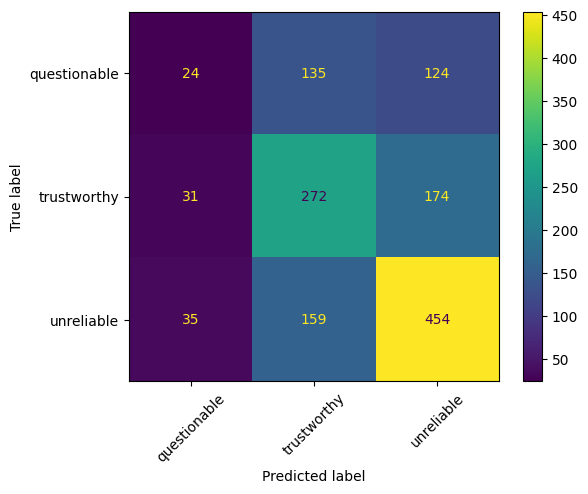

In [123]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.xticks(rotation=45)
plt.show()

## On top of Naive Bayes we will use XGBoost
### After adding 'unrel_proba' as a feature

In [124]:
X_extended = pd.concat([X, unrel_proba], axis=1)

# Adding XGBoost on top of NB (stacking)

In order to look for optimized performance, we have tested several models while also fine-tuning them.

The model that ended up giving thebest accuracy was XGBoost, so we kept that one.

We also tested XGBoost with and without the "statement" column, and got better results without it.
REMINDER: All information needed within "statement" is already included in "unrel_proba", which was calculated using Naive Bayes pecisely using the "statement" information.

We are basically going to stack two models.

## A) Dropping 'statement' column

In [ ]:
X_A = X_extended.drop(columns=["statement"])

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(X_A, y, test_size=0.2)


preprocessor_A = ColumnTransformer(
    transformers = [
        ("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
        ("context", OneHotEncoder(handle_unknown="ignore"), ["context"]),
        ("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
        ("party", OneHotEncoder(handle_unknown="ignore"), ["party"]),
        ("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
        ("speaker_history", "passthrough", ["barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"]),
        ("unrel_proba", "passthrough", ["unrel_proba"])
    ]
)

### XGBoost

In [126]:
pipeline_A_xg = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

# Applying label encoder for XGBoost
le = LabelEncoder()

y_A_train_e = le.fit_transform(y_A_train)
y_A_test_e = le.transform(y_A_test)

#X_A_train_sparse = X_A_train
pipeline_A_xg.fit(X_A_train, y_A_train_e)

cv_results_A_xg = cross_validate(pipeline_A_xg, X_A_train, y_A_train_e, cv=5, scoring='accuracy')

In [127]:
print("XGBoost mean Accuracy: ", cv_results_A_xg["test_score"].mean())

XGBoost mean Accuracy:  0.703870432901115


We use GridSearch for finding the best XGBoost hyperparameters:

In [128]:
grid_xg = [
    {
        "classifier__n_estimators": [100, 300, 500],
        "classifier__max_depth": [3, 6, 10],
        "classifier__learning_rate": [0.01, 0.1, 0.3],
        "classifier__subsample": [0.8, 1.0]
    }
]

search_grid_A_xg = GridSearchCV(
    pipeline_A_xg,
    grid_xg,
    scoring= ['accuracy'], #{'recall': 'recall_macro', 'f1': 'f1_macro'},
    cv=5,
    n_jobs=-1, # parallelize computation,
    refit='accuracy'
)

search_grid_A_xg.fit(X_A_train, y_A_train_e)

print("SearchGrid best_score: ", search_grid_A_xg.best_score_)
print("SearchGrid best_params: ", search_grid_A_xg.best_params_)

SearchGrid best_score:  0.7046521600644864
SearchGrid best_params:  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}


# Overview

## Output

After getting the probability of a statement being unreliable with Naive Bayes, we included this column as a feature in the dataset.
<br>
Then, in another notebook, we tried different models to assess the accuracy of the new dataset (**including probability of statement being unreliable, AND removing the "statement" column**).
<br>
The best option turns out to be the **XGBoost model for the dataset without 'statement'**, with hyperparameters of:
- Learning_rate = 0.1
- Max_depth = 3 
- N_estimators = 500 
- Subsample = 0.8


As demonstrated by the GridSearch. Giving an **accuracy of roughly 70%**.

Now we use the model:

In [129]:
y_pred_2 = pipeline_A_xg.predict(X_A_test)
y_pred_2 = le.inverse_transform(y_pred_2)

# Since we label encoded the target, we will predict values [0, 1, 2]
# We should get back to string values.
y_pred_2


array(['trustworthy', 'trustworthy', 'trustworthy', ..., 'questionable',
       'unreliable', 'unreliable'], dtype=object)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_2)
plt.xticks(rotation=45)
plt.show()

In [130]:
print("Accuracy:", accuracy_score(y_A_test, y_pred_2))
print("Recall macro:", recall_score(y_A_test, y_pred_2, average="macro"))
print("F1 macro:", f1_score(y_A_test, y_pred_2, average="macro"))

print(classification_report(y_A_test, y_pred_2))

Accuracy: 0.7014458772958186
Recall macro: 0.6445482598534478


F1 macro: 0.6515276630486437
              precision    recall  f1-score   support

questionable       0.66      0.38      0.48       534
 trustworthy       0.65      0.71      0.68       873
  unreliable       0.75      0.84      0.79      1152

    accuracy                           0.70      2559
   macro avg       0.69      0.64      0.65      2559
weighted avg       0.70      0.70      0.69      2559



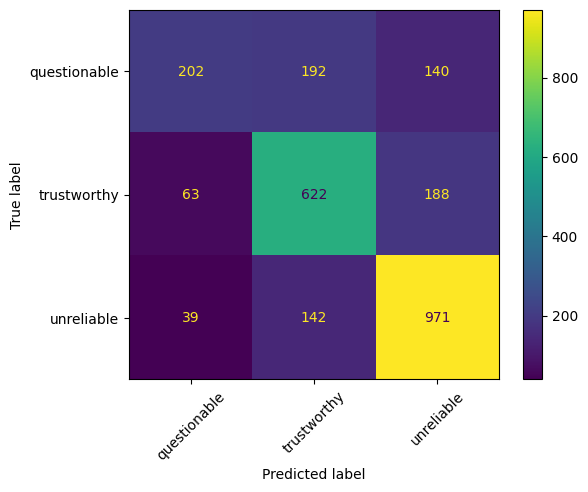

In [131]:
ConfusionMatrixDisplay.from_predictions(y_A_test, y_pred_2)
plt.xticks(rotation=45)
plt.show()

### Exploring results

In [132]:
feature_importance = pd.DataFrame({
    "feature": pipeline_A_xg.named_steps["preprocessor"].get_feature_names_out(),
    "importance": pipeline_A_xg.named_steps["classifier"].feature_importances_
})

feature_importance.sort_values("importance", ascending=False).head(20)

,feature,importance
106,speaker_history__half_true_counts,0.068861
109,unrel_proba__unrel_proba,0.046716
104,speaker_history__barely_true_counts,0.037972
107,speaker_history__mostly_true_counts,0.034161
105,speaker_history__false_counts,0.033655
108,speaker_history__pants_on_fire_counts,0.023507
39,party__party_democrat,0.021202
45,state__state_,0.017441
48,state__state_arizona,0.015565
69,state__state_massachusetts,0.014559


OUTCOME: Model heavily relies on historical credibility of speaker.
<br>
<br> We will try modeling XGBoost without this information to see capacity to predict regardless of speaker.

### No speaker context

In [133]:
speaker_data = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"]
speaker_data_nb = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba"]


X_extended_ns = X_A.drop(columns=["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba"])

X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(X_extended_ns, y, test_size=0.2)

preprocessor_ns = ColumnTransformer(
    transformers = [
        ("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]),
        ("context", OneHotEncoder(handle_unknown="ignore"), ["context"]),
        ("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]),
        ("state", OneHotEncoder(handle_unknown="ignore"), ["state"]),
        ("party", OneHotEncoder(handle_unknown="ignore"), ["party"])
        #("unrel_proba", "passthrough", ["unrel_proba"])
        #("truth_proba", "passthrough", ["truth_proba"])
    ]
)

In [134]:
pipeline_ns_xg = Pipeline([
    ("preprocessor", preprocessor_ns),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

y_ns_train_e = le.fit_transform(y_ns_train)
y_ns_test_e = le.transform(y_ns_test)

#X_A_train_sparse = X_A_train
pipeline_ns_xg.fit(X_ns_train, y_ns_train_e)

cv_results_ns_xg = cross_validate(pipeline_ns_xg, X_ns_train, y_ns_train_e, cv=5, scoring='accuracy')

In [135]:
print("XGBoost mean Accuracy with no speaker information: ", cv_results_ns_xg["test_score"].mean())

XGBoost mean Accuracy with no speaker information:  0.4731232937025836


# Sensitivity Analysis

We have run several scenarios in order to understand where the model's capacity to predict the categories comes from. Those scenarios consist in:

- Naive Bayes Model alone (considering all features). **Accuracy = 54%**
- XGBoost (+ 'unrel_proba' from NB, - 'statement'). **Accuracy = 71%**
- XGBoost (+ 'unrel_proba' from NB, - 'statement' & all speaker data). **Accuracy = 61%**
- XGBoost (- 'statement' & speaker data & 'unrel_proba' from NB). **Accuracy = 46%**

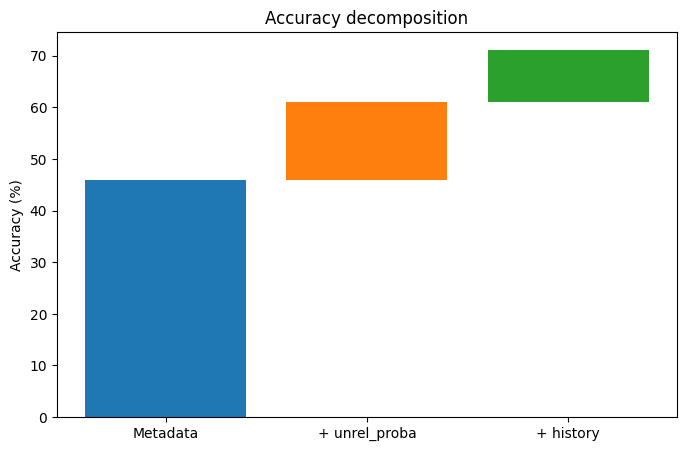

In [136]:
start = 46
add1 = 15
add2 = 10

plt.figure(figsize=(8,5))

plt.bar("Metadata", start)
plt.bar("+ unrel_proba", add1, bottom=start)
plt.bar("+ history", add2, bottom=start+add1)

plt.ylabel("Accuracy (%)")
plt.title("Accuracy decomposition")
plt.show()

In [137]:
speaker_data = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts"]
speaker_data_nb = ["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba"]

meta_columns = X_A.drop(columns=speaker_data_nb).columns.tolist()

In [144]:
dropped_col_acc = {}

for col in meta_columns:
    X_extended_ns = X_A.drop(columns=["speaker", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "unrel_proba", col])

    X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(X_extended_ns, y, test_size=0.2)

    transformers = []

    if "subject" in X_extended_ns.columns:
        transformers.append(("subject", OneHotEncoder(handle_unknown="ignore"), ["subject"]))
    if "context" in X_extended_ns.columns:
        transformers.append(("context", OneHotEncoder(handle_unknown="ignore"), ["context"]))
    if "job_title" in X_extended_ns.columns:
        transformers.append(("job_title", OneHotEncoder(handle_unknown="ignore"), ["job_title"]))
    if "state" in X_extended_ns.columns:
        transformers.append(("state", OneHotEncoder(handle_unknown="ignore"), ["state"]))
    if "party" in X_extended_ns.columns:
        transformers.append(("party", OneHotEncoder(handle_unknown="ignore"), ["party"]))


    preprocessor_ns = ColumnTransformer(
        transformers=transformers
    )

    pipeline_ns_xg = Pipeline([
        ("preprocessor", preprocessor_ns),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ])

    y_ns_train_e = le.fit_transform(y_ns_train)
    y_ns_test_e = le.transform(y_ns_test)

    #X_A_train_sparse = X_A_train
    pipeline_ns_xg.fit(X_ns_train, y_ns_train_e)

    cv_results_ns_xg = cross_validate(pipeline_ns_xg, X_ns_train, y_ns_train_e, cv=5, scoring='accuracy')

    dropped_col_acc[col] = cv_results_ns_xg["test_score"].mean()


print("The contribution of each metadata column on the prediction score is:")
dropped_col_acc

The contribution of each metadata column on the prediction score is:


{'subject': 0.4685311599694568,
 'job_title': 0.46901772185507634,
 'state': 0.456411666979453,
 'party': 0.4531871498762464,
 'context': 0.47400473047604175}

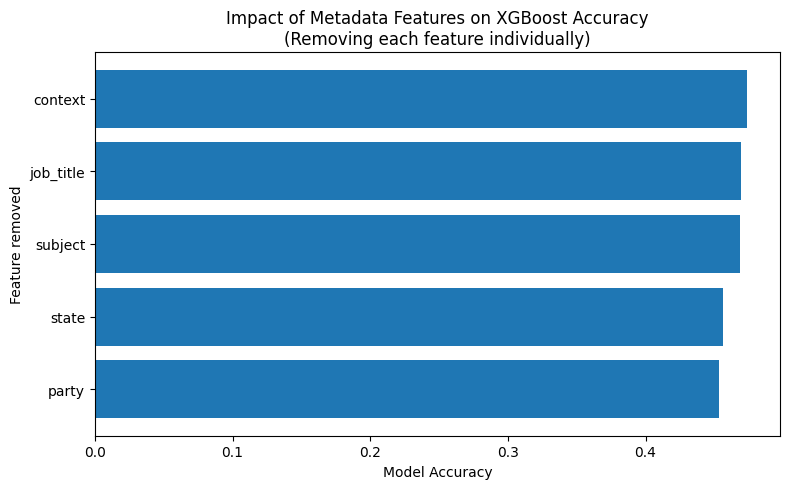

In [145]:
# Convert dictionary to DataFrame
importance_df = pd.DataFrame(
    dropped_col_acc.items(),
    columns=["Feature", "Accuracy Gain"]
)

# Sort by importance
importance_df = importance_df.sort_values(
    by="Accuracy Gain",
    ascending=True
)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"],
    importance_df["Accuracy Gain"]
)

plt.xlabel("Model Accuracy")
plt.ylabel("Feature removed")
plt.title("Impact of Metadata Features on XGBoost Accuracy\n(Removing each feature individually)")
plt.tight_layout()

plt.show()